# US Visa Prediction Project

Machine learning life cycle <br>
1. Understand the problem statement
2. Data collection
3. Exploratory data analysis
4. Data cleaning
5. Model pre-processing
6. Model training
7. choose best Model


## 1) Problem statement.

* OFLC gives job certification applications for employers seeking to bring foreign workers into the United States and grants certifications. 
* As In last year the count of employees were huge so OFLC needs Machine learning models to shortlist visa applicants based on their previous data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to check if Visa get approved or not based on the given dataset.
* This can be used to Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the certain criteria which influences the decision.

# 2. Data Collection <br>
https://www.kaggle.com/datasets/moro23/easyvisa-dataset

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings


In [60]:
warnings.filterwarnings("ignore")

%matplotlib inline

In [61]:
df=pd.read_csv(r"C:\Inception BD\ML Project\end-to-end-machine-learning-project-Visa-approval-prediction-\notebook\EasyVisa.csv")

In [62]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [63]:
df.shape

(25480, 12)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [65]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


# 3. Exploring Data 

In [66]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O'] #define numerical columns
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O'] #define categorical columns

In [67]:
#print columns
print('i have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('i have {} categorical features: {}'.format(len(categorical_features), categorical_features))

i have 3 numerical features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
i have 9 categorical features: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [68]:
# now i need to convert categorical data to numerical data (proportion)
#if a column values are very unique then it is not important helpful for our analysis data, we can remove it
for col in categorical_features:
    print(df[col].value_counts(normalize=True)*100)
    print('---------------------------------------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype:

**Insights**
 - `case_id` have unique vlaues for each column which can be dropped as it it of no importance
 - `continent` column is highly biased towards asia. hence we can combine other categories to form a single category.
 - `unit_of_wage` seems to be an important column as most of them are yearly contracts.

* '''Univariate Analysis'''  <br>
-> Here Uni means one.<br>
-> Univarite analysis means to understand the distribution of values for a single variable <br>

* **Bivariate Analysis:** The analysis of two variables/columns.
* **Multivariate Analysis:** The analysis of two or more variables/columns.

** Univariate analysis on Numerical Features **

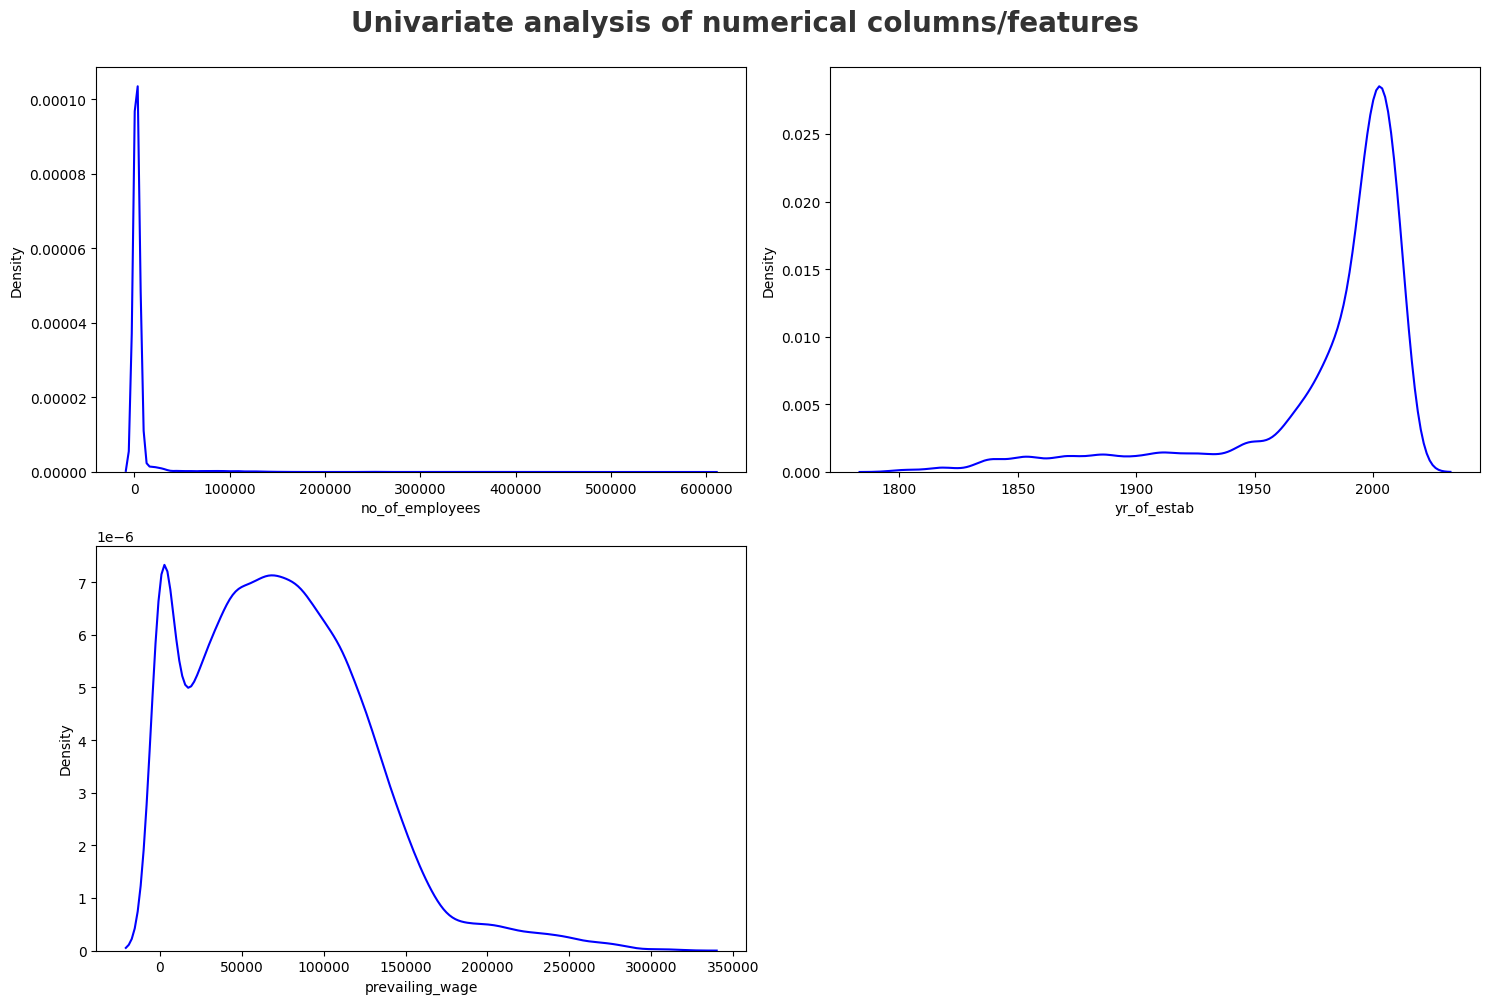

In [69]:
plt.figure(figsize=(15,10))
plt.suptitle('Univariate analysis of numerical columns/features', fontweight='bold', fontsize=20, alpha=0.8, y=1.)

for i in range (0,len(numeric_features)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(x=df[numeric_features[i]],color='blue')
    plt.tight_layout()

* here number of employes right-squid, number of year estab is left-squid
* machine learning good for normal distribution <br> <br>
**Insights**
 - `no_of_employees` column looks more skewed but it may be because of outlies.
 - `yr_of_estab` is a discrete feature.
 - `privailing-wage` is a right-skewed distribution.

** Univariate analysis on Categorical features **

In [70]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

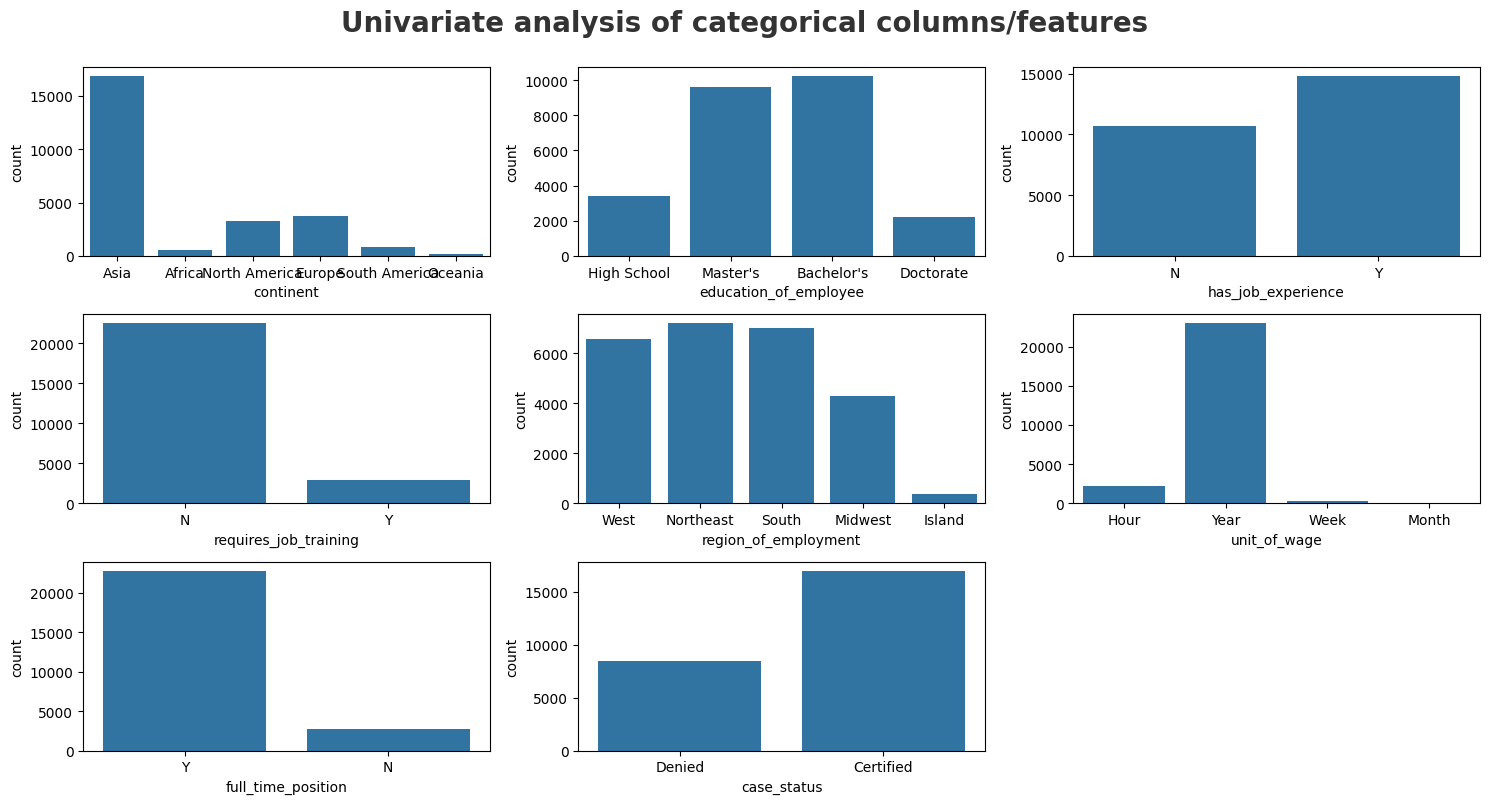

In [71]:
categorical_features.remove('case_id')
plt.figure(figsize=(15,8))
plt.suptitle('Univariate analysis of categorical columns/features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range (0, len(categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()

**Insights**
 - `requires_job_training`, `unit_of_wage`, `full_time_position` and `continents` coulmns have signle category dominating.
 - In rest of the columns are balanced.

* * multivaiate analysis
* multivariate analysis is the analysis where we use more than one variables
1. continuous data (2,3,4,5,5.5,6,7,8,) that means unique (unique value more)
2. dicreate data (2,2,3,4,5,2,7,4,9,2,7) that means same data repeat (unique value lower)

* Multi-variate analysis on numerical features

In [72]:
numeric_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [73]:
discreate_feature_numerical=[feature for feature in numeric_features if len(df[feature].unique())<=25]
continuous_feature_numerical=[feature for feature in numeric_features if len(df[feature].unique())>25]

In [74]:
print('i have {} discreate feature: {}'.format(len(discreate_feature_numerical),discreate_feature_numerical))
print('i have {} continuous feature: {}'.format(len(continuous_feature_numerical),continuous_feature_numerical))

i have 0 discreate feature: []
i have 3 continuous feature: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


* Multi-variate analysis on categorical features


In [75]:
categorical_features

['continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [76]:
discreate_feature_categorical=[feature for feature in categorical_features if len(df[feature].unique())<=25]
continuous_feature_categorical=[feature for feature in categorical_features if len(df[feature].unique())>25]

In [77]:
print('i have {} dicreate feature: {}'.format(len(discreate_feature_categorical),discreate_feature_categorical))
print('i have {} continuous feature: {}'.format(len(continuous_feature_categorical), continuous_feature_categorical))

i have 8 dicreate feature: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']
i have 0 continuous feature: []


In [78]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Check multi-collinearity for categorical features

cor() plot for in between column relationship, need to check this

* here we perform each column with target column, if not relation betwween them, i we will remove it

* **A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test**

* **A chi-square statistic is one way to show a relationship between two categorical variables.**

* **Here we test correlation of Categorical columns with Target column i.e case_status**

Null Hypothesis ($ H_0 $): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis ($ H_1 $): The Feature and Target column are not independent (Correalted)

In [79]:
from scipy.stats import chi2_contingency
chi2_test=[]
for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1]<0.05:
        chi2_test.append('Reject null hypothesis')
    else:
        chi2_test.append('Fail to reject null hypothesis')
result=pd.DataFrame(data=[categorical_features,chi2_test]).T
result.columns=['Column','Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject null hypothesis
1,education_of_employee,Reject null hypothesis
2,has_job_experience,Reject null hypothesis
3,requires_job_training,Fail to reject null hypothesis
4,region_of_employment,Reject null hypothesis
5,unit_of_wage,Reject null hypothesis
6,full_time_position,Reject null hypothesis
7,case_status,Reject null hypothesis


**Report** 
* Here `requires_job_training` fails to Rejects Null Hypothesis which means it doesn't correlate with target column.

* Check null values


In [80]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [81]:
continues_feature=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('num of continues feature: ',continues_feature)

num of continues feature:  ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


* Boxplot and Stacked-histogram over continues_feature

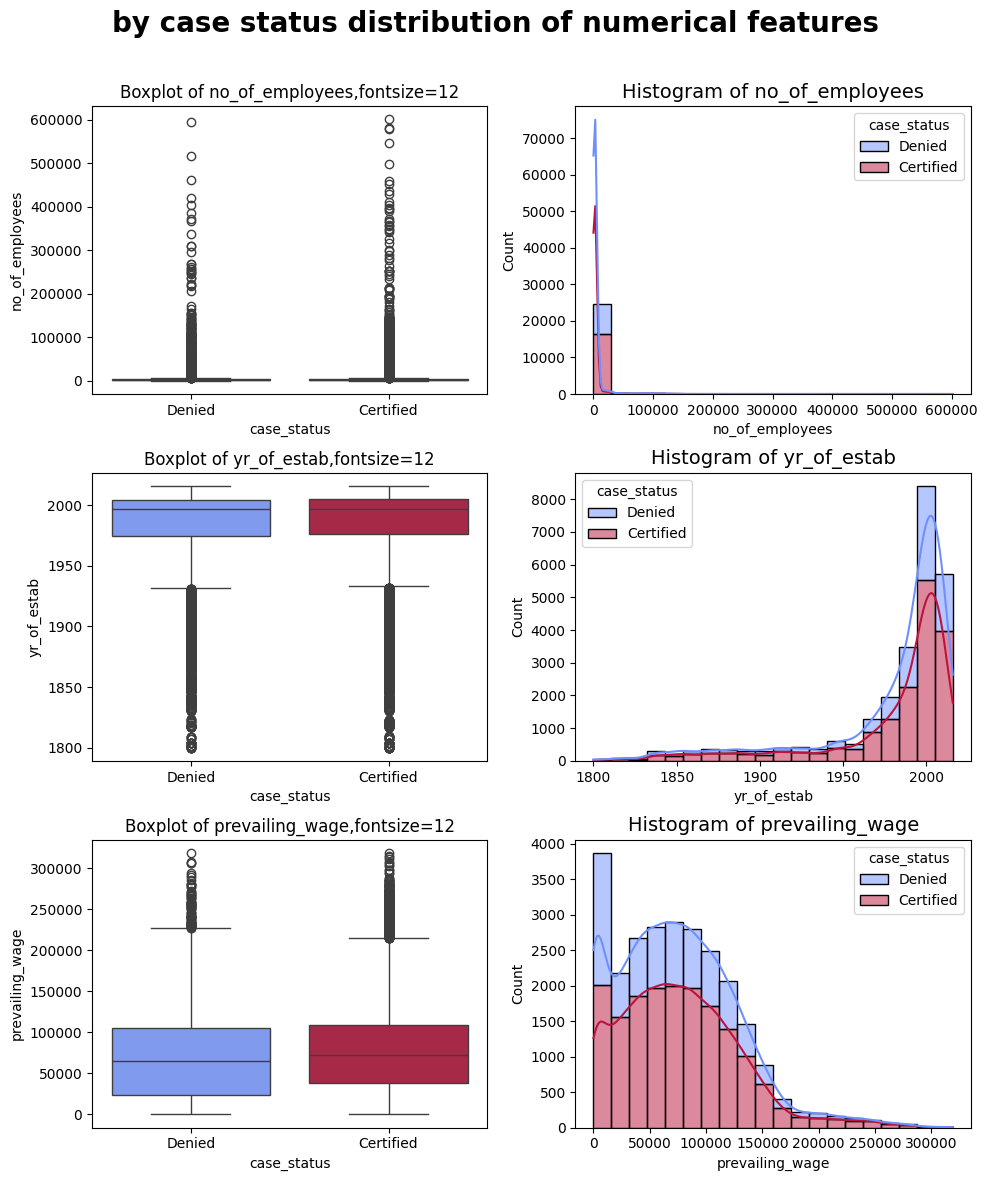

In [82]:
clrl=['#6E90FF','#BB143D']
fig,ax=plt.subplots(3,2,figsize=(10,12))
fig.suptitle('by case status distribution of numerical features', color='black', fontsize=20,fontweight='bold',ha='center')
for i, col in enumerate(continues_feature):
    sns.boxplot(data=df,x='case_status',y=col,palette=clrl,ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col},fontsize=12')
    sns.histplot(data=df,x=col,hue='case_status',bins=20,kde=True,multiple='stack',palette=clrl,ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.90)

* ` Initial analysis report `

* **No of Employees has many outliers which can be Handled in Feature Engineering and `no_of_employees` is Right Skewed.**
* **`yr_of_estab` is left skewed and some outliers below the lower bound of Box plot.**
* **`prevailing_wage` is right skewed with outliers above upper bound of box plot.**
* **There are No missing values in the dataset.**
* **The `case_id` column can be deleted because each row has unique values.**
* **The `case_status` column is the target to predict.**
* **In the Categorical column, features can be made Binary numerical in feature Encoding**

# 4. Visualization

* 4.1 Visualize the target feature

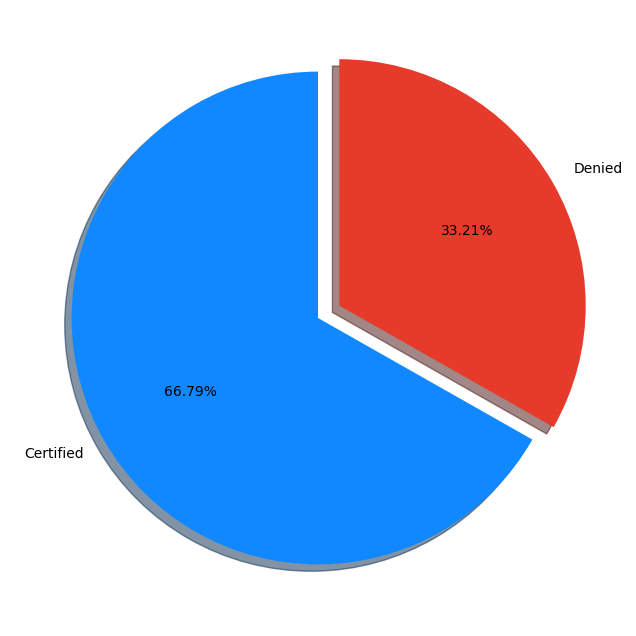

In [87]:
parcentage=df.case_status.value_counts(normalize=True)*100
labels=["Certified","Denied"]

fig,ax=plt.subplots(figsize=(15,8))
explode=(0,0.1)
colors=['#1188ff','#e63a2a']
ax.pie(parcentage, labels=labels,startangle=90,autopct='%1.2f%%',explode=explode,shadow=True,colors=colors)
plt.show()

* From the chart it is seen that the Target Variable is Imbalanced

Imbalanced data are types of data where the target class has an uneven distribution of observations, i.e Here Denied value has more count than the Certified value of the dataset.

had applicant continent any impact on Visa status?

In [88]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

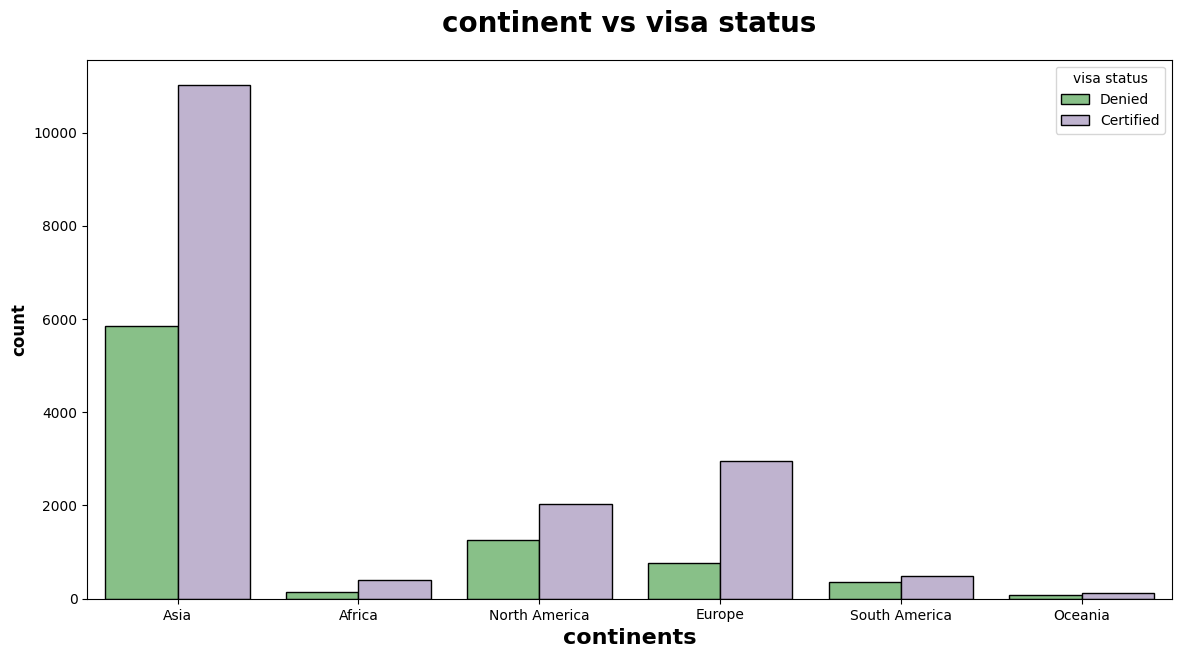

In [89]:
plt.subplots(figsize=(14,7))
sns.countplot(x="continent", hue="case_status",data=df,ec="black",palette="Accent")
plt.title("continent vs visa status", weight="bold", fontsize=20,pad=20)
plt.ylabel("count", weight="bold",fontsize=12)
plt.xlabel("continents", weight="bold", fontsize=16)
plt.legend(title="visa status", fancybox=True)
plt.show()


In [90]:
df2=df.copy()

In [92]:
df2.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


see the percentage of certified

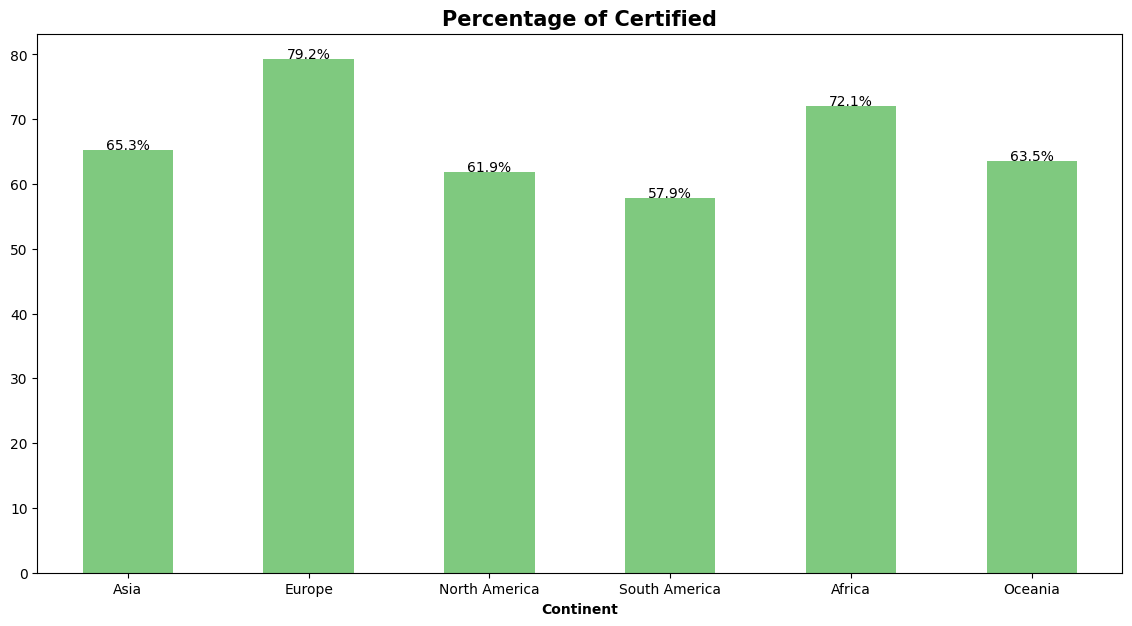

In [93]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['continent'].value_counts()/df2['continent'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Continent' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Report:**
* As per the Chart Asia applicants applied more than other continents.
* 43% of Certified applications are from Asia.
* This is followed by Europe with 11% of Certified applications.
* Highest chance of getting certified if you are from `Europe` and followed by `Africa`

* 4.3 now check education_of_employee with case_status, that means what is relationsship between them

In [94]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

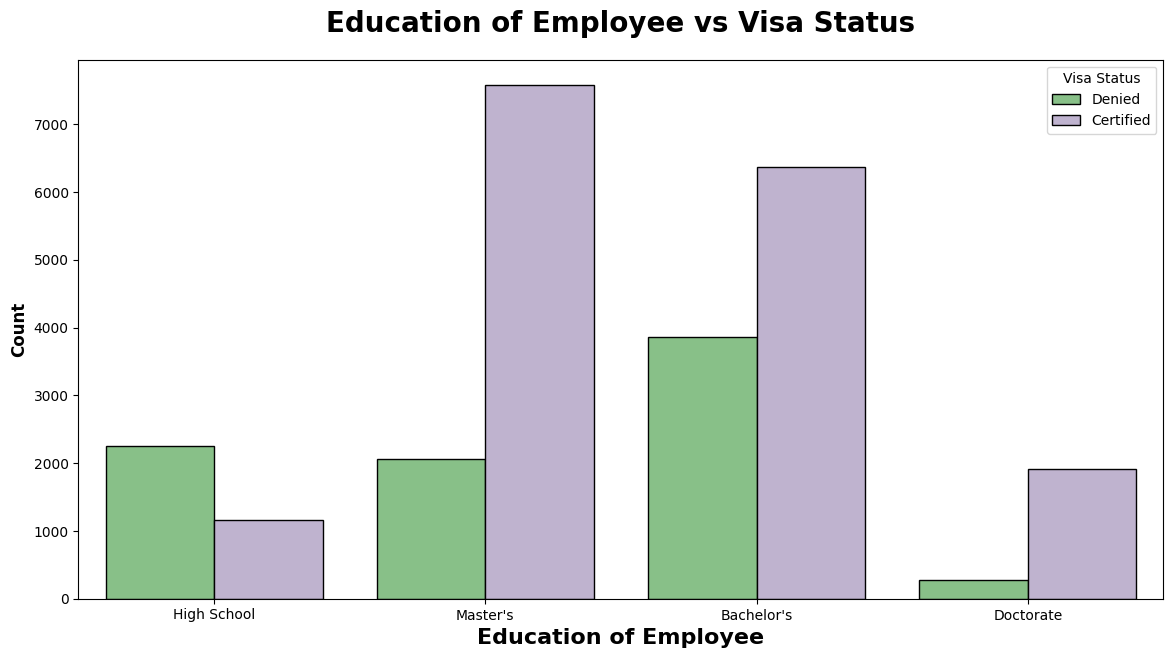

In [95]:
plt.subplots(figsize=(14,7))
sns.countplot(x="education_of_employee",hue="case_status", data=df, ec = "black",palette="Accent")
plt.title("Education of Employee vs Visa Status", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Education of Employee", weight="bold", fontsize=16)
plt.legend(title="Visa Status", fancybox=True)
plt.show()

now check the percentage

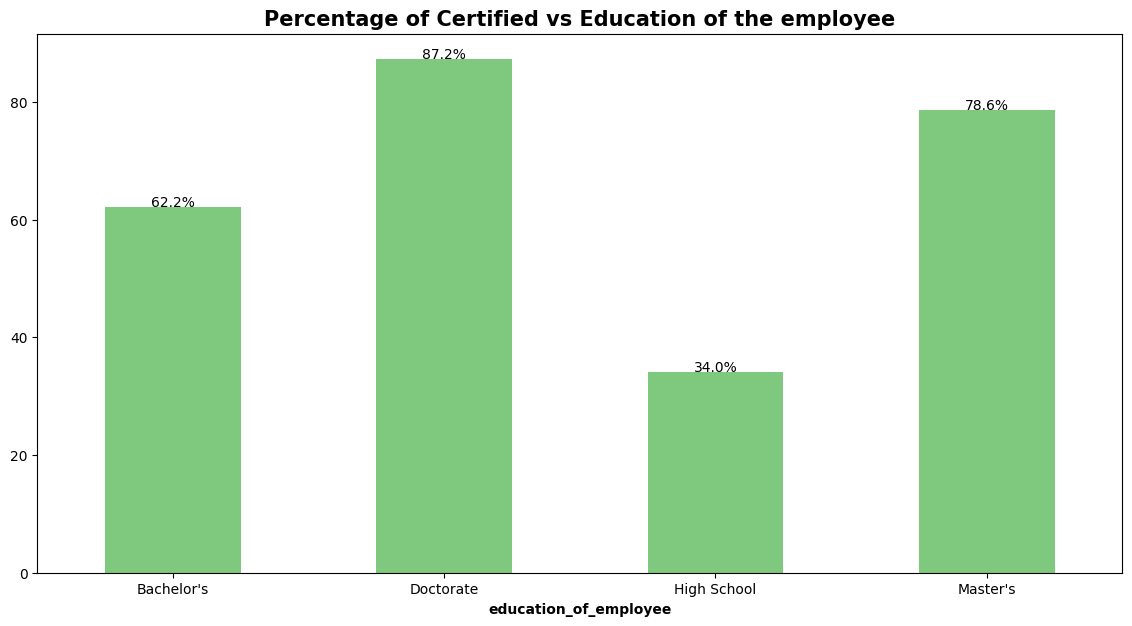

In [96]:
plt.figure(figsize=[14,7])

(100*df2[df2["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts()).plot(
    kind='bar',stacked=True , colormap='Accent')
plt.title("Percentage of Certified vs Education of the employee" , fontsize = 15, fontweight ='bold'  )
order1 = (100*df2[df2["case_status"].isin(['Certified'])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt='{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('education_of_employee' , fontweight ='bold')
plt.xticks(rotation=0)
plt.show()

**Insights**
- education status has high impact
- `Doctorate` and `Master's` graduates have higher cange of being accepted then the others.